In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)

In [2]:
# ---------------------------------------------------------
# Step 1 : Load Dataset
# ---------------------------------------------------------

url = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/"
    "Module%203/data/ChurnData.csv"
)

df = pd.read_csv(url)

# Display first 5 rows
display(df.head())

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [3]:
# ---------------------------------------------------------
# Step 2 : Select Only Required Features
# ---------------------------------------------------------

selected_features = [
    "tenure",
    "age",
    "address",
    "income",
    "ed",
    "employ",
    "equip",
]

target = "churn"

df = df[selected_features + [target]]

# Convert target variable to integer
df[target] = df[target].astype(int)

display(df.head())

,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0


In [4]:
# ---------------------------------------------------------
# Step 3 : Split Features (X) and Target (y)
# ---------------------------------------------------------

X = df[selected_features]
y = df[target]

print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (200, 7)
Shape of y : (200,)


In [5]:
# ---------------------------------------------------------
# Step 4 : Train-Test Split
# ---------------------------------------------------------
# IMPORTANT:
# Split BEFORE scaling to prevent Data Leakage.
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
# ---------------------------------------------------------
# Step 5 : Feature Scaling
# ---------------------------------------------------------
# Fit ONLY on training data.
# Transform both train and test data.
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# ---------------------------------------------------------
# Step 6 : Train Logistic Regression Model
# ---------------------------------------------------------

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [8]:
# ---------------------------------------------------------
# Step 7 : Make Predictions
# ---------------------------------------------------------

y_pred = model.predict(X_test_scaled)

# Probability of each class
y_prob = model.predict_proba(X_test_scaled)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 5 Probability Predictions:")
print(y_prob[:5])

First 10 Predictions:
[0 0 0 0 0 0 1 1 0 0]

First 5 Probability Predictions:
[[0.97827859 0.02172141]
 [0.95597206 0.04402794]
 [0.90401495 0.09598505]
 [0.97570524 0.02429476]
 [0.95124753 0.04875247]]


In [9]:
# ---------------------------------------------------------
# Step 8 : Evaluate Model
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

loss = log_loss(y_test, y_prob)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Log Loss : {loss:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.7250
Log Loss : 0.5489

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.86      0.81        28
           1       0.56      0.42      0.48        12

    accuracy                           0.72        40
   macro avg       0.66      0.64      0.64        40
weighted avg       0.71      0.72      0.71        40


Confusion Matrix
[[24  4]
 [ 7  5]]


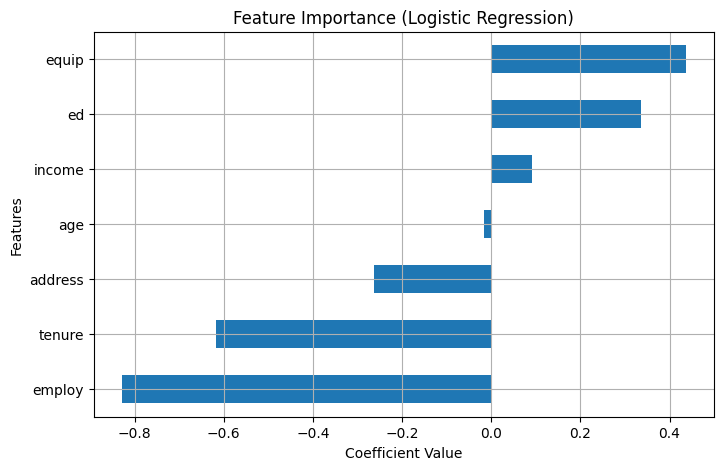

In [10]:
# ---------------------------------------------------------
# Step 9 : Feature Importance
# ---------------------------------------------------------
# Positive coefficient -> increases chance of churn
# Negative coefficient -> decreases chance of churn
# ---------------------------------------------------------

coefficients = pd.Series(
    model.coef_[0],
    index=selected_features
)

coefficients = coefficients.sort_values()

plt.figure(figsize=(8,5))
coefficients.plot(kind="barh")

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.grid(True)
plt.show()